# Generate data by running Basener's script

Here we run an excerpt of the JavaScript embedded in William Basener's [Realistic Mutation-Selection Modeling](https://people.rit.edu/wfbsma/evolutionary%20dynamics/EvolutionaryModel.html) webpage, and generate the data that Basener and Sanford report upon in Section 5.

**What Basener and Sanford actually did to generate their data is quite different from what they indicate in the article.**

1. Basener and Sanford did not, as they claim in the introduction to Section 5, hold essential parameters constant. The lower limit of the interval of fitnesses, and also the spacing of points within the interval, vary from one case to the next.

2. Basener and Sanford did not run their "simulation" with no mutations, as claimed in Sections 5.1 and 5.2 of the article, but instead calculated the value of a simple formula.

3. Basener's script does not set the standard deviation of the Gaussian distribution of mutation effects as Basener and Sanford claim in Section 5.3.

**The figures in the article are inconsistent with one another, as are the figures on Basener's webpage.**

In the Gamma case (Section 5.4), two of the line plots show the mean fitness decreasing to -0.014 in year 2500 (this is the value that Basener and Sanford report in the text), while the "Population Distribution" plot shows that the mean fitness decreases to -0.017. The same inconsistency appears at the webpage, with the "Population Distribution" plot indicating in text that the mean fitness reaches -0.017. Inspecting the data, we find that -0.017 is the correct value.


## Determining how B&S subdivided the fitness interval

The interval of Malthusian growth factors (fitnesses) is not user-adjustable, but it varies in the figures of the article. Thus it appears that Basener and Sanford ran different versions of the code in different cases. We'll work with the hard-coded interval $[-0.1,\, 0.15],$ and set the "number of discrete population fitness values" parameter of Basener's webpage to obtain matches to the figures in the article. 
 
Basener and Sanford claim that the initial frequency distribution is a discretized normal distribution $\mathcal{N}(0.044,\, 0.005)$ in all cases. It appears that this is true, and we proceed under the assumption that it is in fact true. This allows us to transform the maximum of the initial frequencies, obtained by eyeballing a figure in the article, into an estimate of the number of subintervals in the partition of the interval of growth factors.

We begin by inspecting the relevant passage in Basener's code. First the probabilty *density* `P` is calculated at all fitnesses `m[i]`, excepting those that differ from the mean by more than 11.2 standard deviations.


```javascript
var mean = 0.044;
var stdev = 0.005;
var fitnessRange = [-0.1, 0.15];
var numStDev = 11.2;
// snip
var minFitness = mean - numStDev * stdev;
var maxFitness = mean + numStDev * stdev;


GaussianMultiplicativeTerm = 1 / (stdev * Math.sqrt(2 * Math.PI));
// Correct error: last iteration assigns to memory out of bounds
for (i = 0; i < numIncrements /* + 1 */; i++) { 
    P[i] = GaussianMultiplicativeTerm * Math.exp(-0.5 * Math.pow((m[i] - mean) / stdev, 2));
    if (m[i] < minFitness) {
        P[i] = 0
    };
    if (m[i] > maxFitness) {
        P[i] = 0
    };
}
```

The result of (inaccurately) normalizing the array `P` of probability densities is assigned to the initial frequency distribution `Psolution[0]`.

```javascript   
s = 0;
for (i = 0; i < numIncrements; i++) {
    s = s + P[i]
}

var maxPinitial = 0;
for (var i = 0; i < numIncrements; i++) {
    Psolution[0][i] = P[i] / s;
    PsolutionForPlot[0][i] = P[i] / s;
    maxPinitial = Math.max(maxPinitial, PsolutionForPlot[0][i]);
}
```

Note that it is not the array `P`, but instead the array `Psolution`, that corresponds to $P$ in the article. `P` is merely a temporary variable. It is used only in calculating the initial frequency distribuiton `Psolution[0]`. The array `PsolutionForPlot`, which is used in generating the figures that we inspect, stores the normalized frequency distributions. **In the Python code of this binder, the variable `P` corresponds to $P$ in the article, and to `Psolution` in Basener's script.**

Our first objective, in responding to each of the subsections of Section 5, is to determine the value of `numIncrements`, set according to the "number of discrete population fitness values" input on Basener's webpage, from the value of `maxPinitial`, which we estimate by looking at a figure in the article. We will verify that the following function produces the correct result.

In [162]:
%matplotlib notebook
"""
Load the code base.
"""
%run ../Code/bs.py
%run -i ../Code/multiprecision_gamma.py
%run -i ../Code/gamma.py

distribution = stats.norm(0.044, 0.005)

def n_fitnesses(max_initial_frequency):
    density_at_mean = distribution.pdf(distribution.mean())
    delta = max_initial_frequency / density_at_mean
    return round((0.15 - -0.1) / delta)

## Section 5.2: No mutations

In this case, the conditions under which Basener and Sanford generated their data are radically different from those that they report. Let's begin with the easy determination. The frequency of the mean fitness in [Figure 2](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig2_HTML.gif) is about 0.032, and thus the approximate number of fitnesses is:

In [2]:
n_fitnesses(0.032)

623.0

The fitness interval in Figure 2 is 25 percent shorter than the interval for the current version of Basener's code. So we gather that Basener and Sanford set the "number of discrete population fitness values" to 500 for the shorter interval, and that we should set the parameter to 625 for the longer interval.


Now we move to the difficult part. In Section 5.2, Basener and Sanford claim to "present a simulation," having explained:

>To remain biologically realistic, we assume a finite population: any subpopulation $P_i$  that contains less than some fraction of the population is assumed to contain zero organisms. For the numerical simulations, we set \[the frequency\] $P_i=0$  whenever $P_i$  is less than $10^{-9}$  of the total population.

In concrete terms, Basener and Sanford claim that they always select the "Finite" option on Basener's webpage. However, what the code actually does is to scale the threshold $10^{-9}$ by the maximum of the frequencies, not by their sum. Here is the relevant passage in Basener's JavaScript:

```javascript
if (PopSize == "Finite") {
    maximumP = Math.max.apply(Math, Psolution[t]);
    for (i = 0; i < numIncrements; i++) {
        Psolution[t][i] = Psolution[t][i] * (Psolution[t][i] > maximumP * 0.000000001);
    }
}
```

In the absence of mutation, when a frequency is set to zero, it remains zero forevermore. At the beginning of a run, the maximum fitness with a frequency above threshold is 0.076. 

In [3]:
n = 625
fitnesses = np.linspace(-0.1, 0.15, n + 1)
bin_width = (fitnesses[-1] - fitnesses[0]) / n
frequencies = distribution.pdf(fitnesses) * bin_width
frequencies /= math.fsum(frequencies)
threshold = 1e-9 * np.max(frequencies)
np.max(fitnesses[frequencies >= threshold])

0.07600000000000001

Running the code at the webpage for 3500 years, with the options "Finite" and "None (selection, no mutation)," you will see that the maximum fitness with nonzero frequency is indeed 0.076. However, the maximum in  [Figure 4](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif) of the article is about 0.10. **Thus it cannot be the case that Basener and Sanford made the population "finite" as they claim.** Simply switching to the "Infinite" option does not give a match of Figure 4. Basener and Sanford did not generate their data with the setting "None (selection, no mutation),"  referred to as `None` within the code. They instead generated it with the setting "None using exact solution exponential formula," referred to as `NoneExact` within the code. 

Obviously, use of a formula to calculate an exact solution is not a simulation. But that is what makes Basener's webpage generate results matching those in the article. With the "number of discrete population fitness values" set to 625, the depiction of the initial distribution on the webpage is a good match for that in the article. Furthermore, with "mutation distribution type" of `NoneExact` ("None using exact solution exponential formula"), the mean fitness is 0.05 after 250 years, as stated explicitly in [Figure 2](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig2_HTML.gif), and is 0.063 after 750 years, as stated explicitly in [Figure 4](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif). Furthermore, the final distribution matches that of Figure 4, and the final distributions obtained with parameter settings of 600 and 650 (instead of 625) do not match that of Figure 4.

We will delve into the difference between the `None` and `NoneExact` options, which turns out to be important, in [Replication of Section 5.2 (No Mutations)](2_No_Mutations.ipynb). Thus we use Basener's code to generate data for both.

### Mutation type `NoneExact`

In the next cell, we generate a command line `c` to run the script, and then submit it to the command line interpreter (shell) of the host computer. Then we load the JSON output of the script, convert it to a Python dictionary, and dump the pickled dictionary to a gzipped file.

In [4]:
%%time
case = 'NoneExact'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_2desired.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2desired')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2desired.json
Done.
CPU times: user 5.92 s, sys: 831 ms, total: 6.75 s
Wall time: 1min 7s


Now we load the data, and verify that the maximum of the intial frequencies is about 0.032, as we see in Figure 2 of the article.

In [5]:
with gzip.open('../Basener_Sanford_Data/bs5_2desired.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.03191538243211459

Next we plot the data that we have just loaded, and obtain a good match for the corresponding figure in the article.

In [3]:
# %load ../Code/bs_plot.py
def bs_plot(frequencies, m, intermediate):
    fig, ax = plt.subplots()
    ax.set_xlabel('Malthusian Growth Factor (Fitness)')
    ax.set_ylabel('Proportion')
    years = [0, intermediate, len(frequencies) - 1]
    colors = ['r', 'b', 'limegreen']
    for year, color in zip(years, colors):
        p = frequencies[year] / math.fsum(frequencies[year])
        mean = math.fsum(p * m)
        label = 'Year {0} (mean {1:.3f})'.format(year, mean)
        ax.plot(m[p>0], p[p>0], color=color, label=label)
    ax.legend(loc='best')
    return fig, ax

<IPython.core.display.Javascript object>


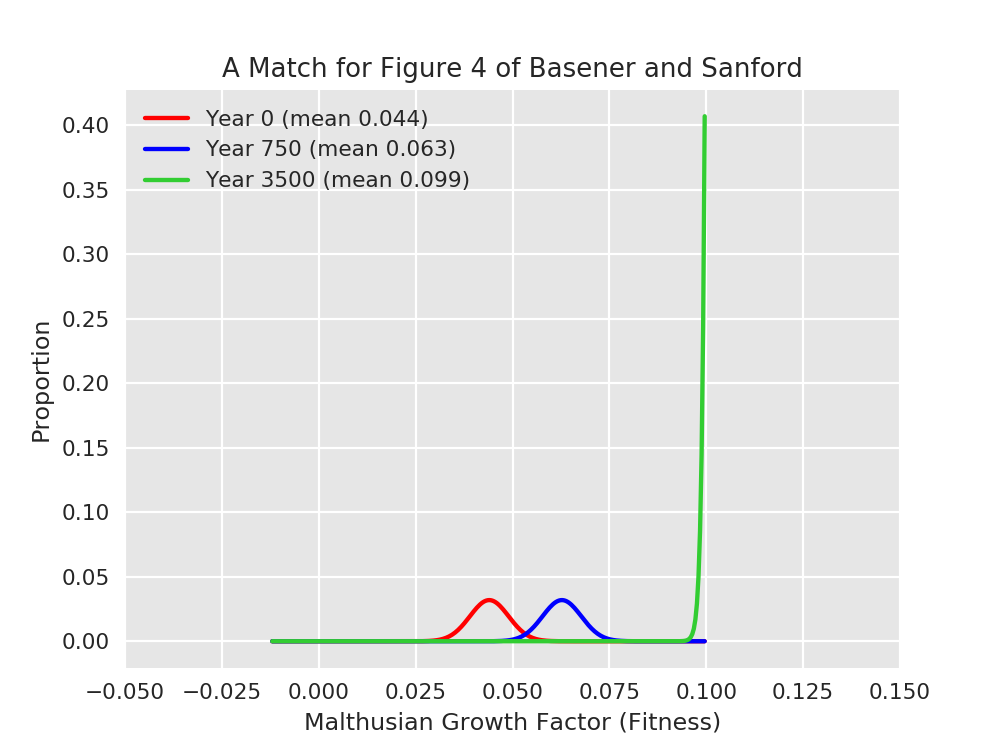

In [7]:
fig, ax = bs_plot(data['Psolution'], data['m'], 750)
ax.set_title('A Match for Figure 4 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15)
save_ylim = ax.get_ylim()

**Figure 4 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" /></a>


Click on the image for full resolution.

We also establish that we can redo the formulaic calculation using the data that Basener's code operated upon. Note that `np.outer(t, m)` produces the outer product of the vectors `t` of times (years) and `m` of Malthusian growth factors of the types of organism.

In [8]:
m = data['m']
t = np.arange(data['numYears'])
P0 = data['Psolution'][0]
P = P0 * np.exp(np.outer(t, m))
maximum_absolute_relative_error(P, data['Psolution'])

4.440892098500626e-16

Assuming that there is no loss of precision in the JSON output of `BS.js` (there is not supposed to be), then we are seeing the effects of slight differences in implementation of the exponential function. There's nothing at all surprising or worrisome about such a tiny discrepancy. Note that the significands of the numbers are 53 bits in length, and that the value of $2^{-53}$ is:

In [9]:
2 ** -53

1.1102230246251565e-16

### Mutation type `None`

Now we do much the same as in the `NoneExact` case. 

In [10]:
%%time
case = 'None'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_2actual.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2actual')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2actual.json
Done.
CPU times: user 6.05 s, sys: 689 ms, total: 6.74 s
Wall time: 1min 7s


The maximum of the initial frequencies should be exactly the same in this case as in the `NoneExact` case.

In [11]:
with gzip.open('../Basener_Sanford_Data/bs5_2actual.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.03191538243211459

The crucial feature to note in the following plot is the maximum proportion in year 3500. I've set the the limits on the y-axis as in the preceding figure, to make it plain that the maximum is much less than in Figure 4 of the article.

<IPython.core.display.Javascript object>


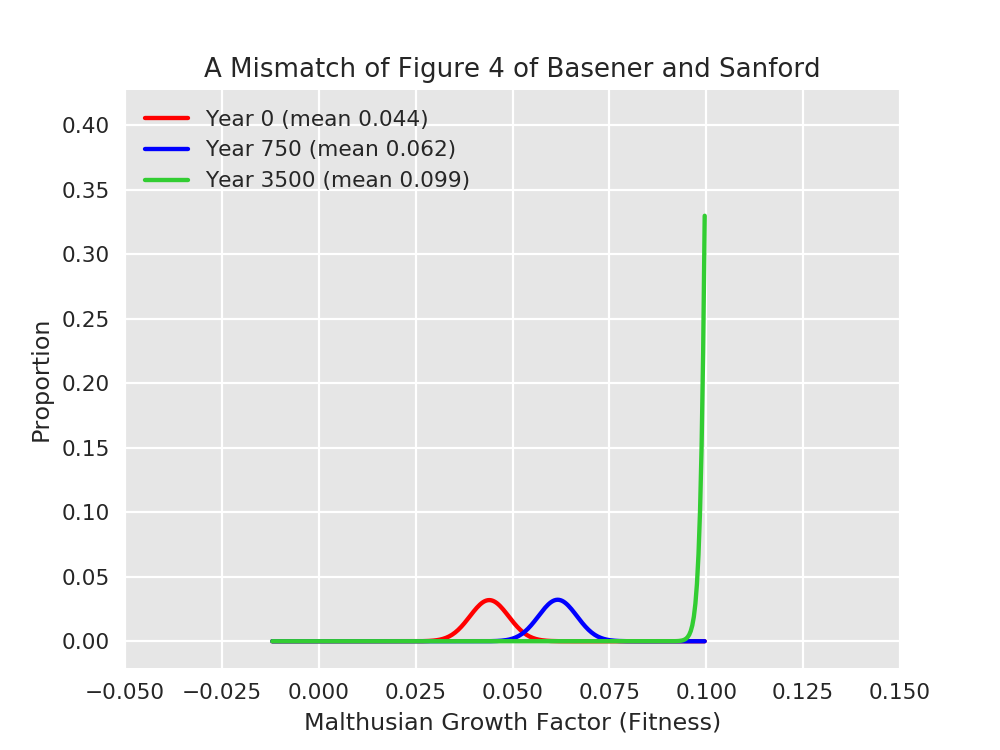

In [12]:
fig, ax = bs_plot(data['Psolution'], data['m'], 750)
ax.set_title('A Mismatch of Figure 4 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15)
ax.set_ylim(save_ylim);

**Figure 4 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif" /></a>


Click on the image for full resolution.

## Section 5.3: Gaussian

The standard deviation in Basener's code is 0.0005, which is just one-fourth of the value 0.002 reported in the article. Running the code at Basener's webpage gives nothing close to a match of [Figure 7](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif) in the article. So I have changed the standard deviation to 0.002 in [`BS.js`](../Code/BS.js).

The fitness interval is the same as in Section 5.2, but the greatest of the initial frequencies is about 0.08, not 0.032 as before. Our initial estimate of the "number of discrete population fitness values" is:

In [13]:
n_fitnesses(0.08)

249.0

This indicates that Basener and Sanford set the number to 200 for the shorter interval of growth factors (fitnesses), and that we should set it to 250 for the longer interval. Again, there is no mention of the different handling in the article.

In [14]:
%%time
n = 250
case = 'Gaussian'
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_3.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_3')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_3.json
Done.
CPU times: user 353 ms, sys: 50 ms, total: 403 ms
Wall time: 3.06 s


We verify that the maximum of the initial frequencies is about 0.08.

In [15]:
with gzip.open('../Basener_Sanford_Data/bs5_3.pickled.gz') as f:
    data = pickle.load(f)
np.max(data['Psolution'][0])

0.07978845608028644

<IPython.core.display.Javascript object>


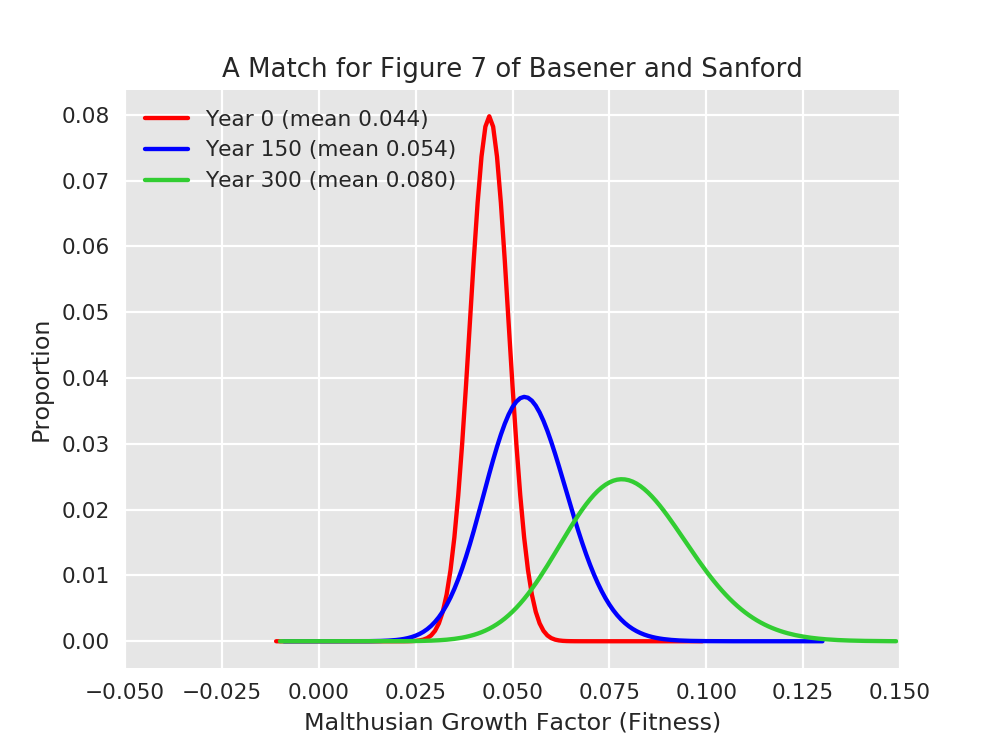

In [16]:
fig, ax = bs_plot(data['Psolution'], data['m'], 150)
ax.set_title('A Match for Figure 7 of Basener and Sanford')
ax.set_xlim(-0.05, 0.15);

**Figure 7 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig7_HTML.gif" /></a>


Click on the image for full resolution.

## Section 5.4: Gamma

Only in Section 5.4 does the interval of fitness values match that of Basener's webpage. The maximum of the initial frequencies in [Figure 10](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif) is about 0.04. Our initial estimate of the number of points in the fitness interval is:

In [3]:
n_fitnesses(0.04)

499.0

Basener and Sanford report the number 500, and it appears that we should believe them in this case. Running the code at Basener's webpage with the "number of discrete population fitness values" set to 500, the resulting figures are good matches for the figures in Section 5.4. However, when we attempt a detailed comparison of numeric data to the figures, we discover that the figures are not consistent with each other.

In [4]:
%%time
n = 500
case = 'Gamma'
c = bs_command(percentage_of_mutations_that_are_beneficial=0.001,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BS.js',
               output_path='../Basener_Sanford_Data/bs5_4.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_4')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_4.json
Done.
CPU times: user 1.09 s, sys: 132 ms, total: 1.22 s
Wall time: 14.2 s


We verify that the maximum of the initial frequencies is about 0.04, as in [Figure 10](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif) of the article.

In [5]:
with gzip.open('../Basener_Sanford_Data/bs5_4.pickled.gz') as f:
    bs5_4 = pickle.load(f)
np.max(bs5_4['Psolution'][0])

0.03989422804014321

Now we produce a plot matching Figure 10.

<IPython.core.display.Javascript object>


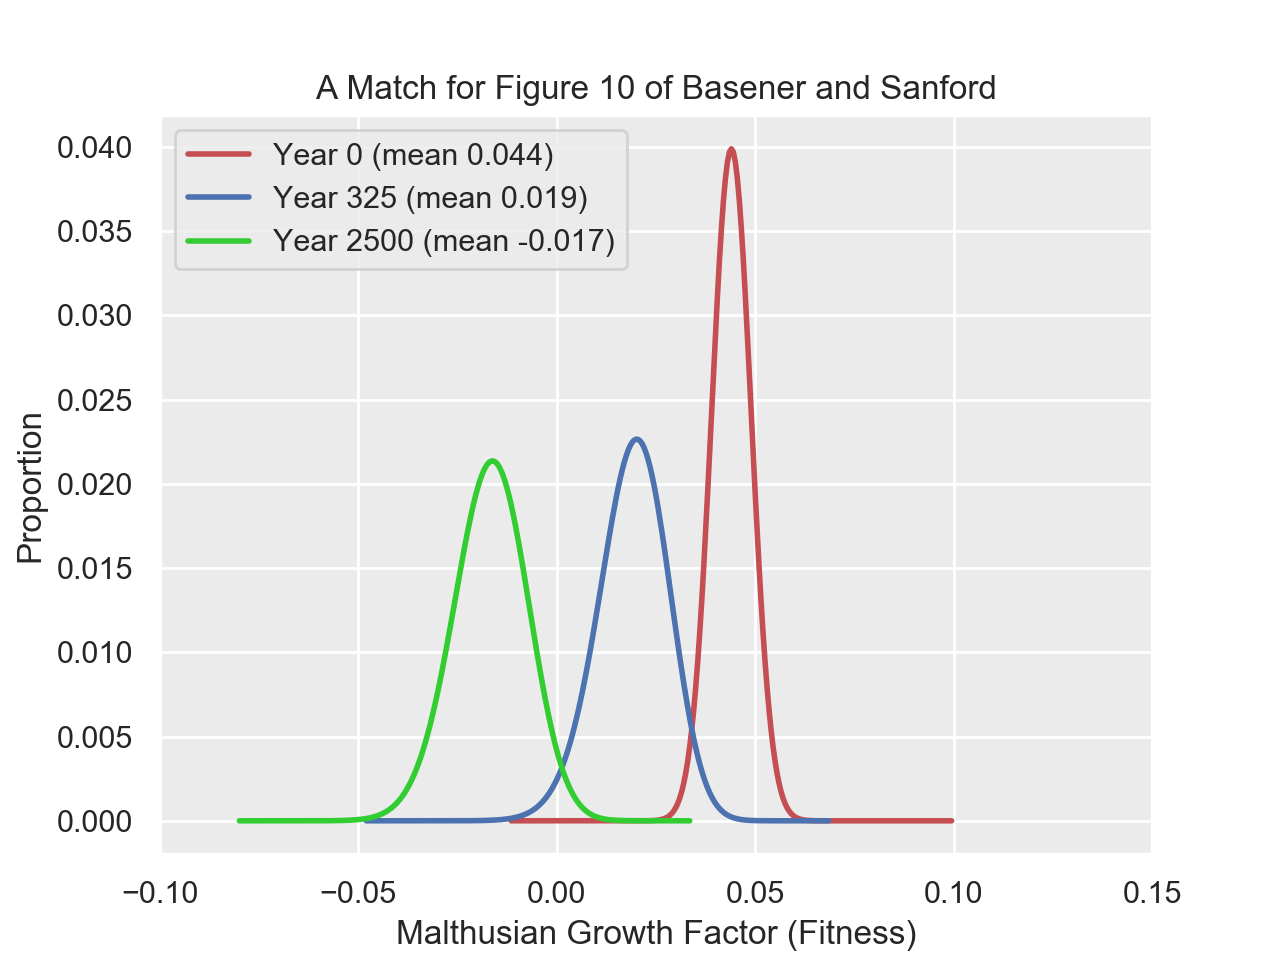

In [6]:
fig, ax = bs_plot(bs5_4['Psolution'], bs5_4['m'], 325)
ax.set_title('A Match for Figure 10 of Basener and Sanford')
ax.set_xlim(-0.10, 0.15);

**Figure 10 of Basener and Sanford**


<a href="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif" target=_>
<img style="float: left; width: 20%; margin-left: 2%; margin-right: 78%; margin-bottom: 1em;" src="https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig10_HTML.gif" /></a>


Click on the image for full resolution.

In [282]:
%%time

def f_matrix(p, normed=True):
    """
    Returns [f_ij] matrix; columns are normalized if `normed` is true.
    """
    n = len(p) // 2 + 1
    f = np.empty((n, n), dtype=type(p[0]))
    for j in range(n):
        col = f[:,n-j-1]
        col[:] = p[j:n+j] 
        if normed:
            col /= math.fsum(col)
    return f

def neutral_probabilities(p = bs5_4['mutation_probs']):
    """
    Returns (incorrect, correct) probabilities of neutral mutation.
    """
    n_classes = len(p) // 2 + 1
    f = f_matrix(p, normed=False)
    incorrect = f[np.diag_indices(n_classes)]
    non_neutral_prob = np.subtract(np.sum(f, axis=0), incorrect)
    correct = 1 - non_neutral_prob
    return incorrect, correct


def print_relative_errors(incorrect, correct, transform=None):
    errors = relative_error(incorrect, correct)
    if not (transform is None):
        errors = transform(errors)
    print('   Min :', float(np.min(errors)))
    print('   Mean:', float(np.mean(errors)))
    print('   Max :', float(np.max(errors)))


print('Relative errors of incorrect probabilities of neutral mutation')
print_relative_errors(*neutral_probabilities())

Relative errors of incorrect probabilities of neutral mutation
   Min : -0.7803917431277958
   Mean: -0.45110287680786837
   Max : -0.44789842324473417
CPU times: user 4.02 ms, sys: 1.93 ms, total: 5.94 ms
Wall time: 4.31 ms


In [288]:
p = mp_float(bs5_4['mutation_probs'])
f = f_matrix(p, normed=False)
MP = bs5_4['b'] * f
print_relative_errors(MP[:,1:].flatten(), bs5_4['MP'][:,1:].flatten())

   Min : -4.187096799984463e-14
   Mean: 1.0938445786068447e-17
   Max : 1.508565006013216e-14


In [263]:
a=np.arange(9.).reshape((3,3))
print(a)
v = np.sum(a, axis=0)
print(v)
print(a * (1/v))
print(a / v)
a /= v
print(a)
np.sum(a, axis=0)

[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]
[ 9. 12. 15.]
[[0.         0.08333333 0.13333333]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.58333333 0.53333333]]
[[0.         0.08333333 0.13333333]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.58333333 0.53333333]]
[[0.         0.08333333 0.13333333]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.58333333 0.53333333]]


array([1., 1., 1.])

**Check the accuracy of Basener's calculations of $\Delta \cdot g((i - j)\Delta.$**

In [18]:
def accurate_mutation_probs():
    delta = mp.mpf('0.0005')
    w = mp.mpf('0.001')
    g = MultiprecisionGamma()
    n = 500
    effects = delta * np.array(mp.linspace(1, n - 1, n - 1))
    masses = delta * g.pdf(effects)
    positive = w * masses
    negative = (1 - w) * masses
    neutral = (1 - w) * delta * gamma_density(delta)
    return np.concatenate((negative[::-1], [neutral], positive))

In [59]:
print("Recalculating mutation probabilities with high precision")
print("Error of Basener's probabilities relative to ours")
print_relative_errors(bs5_4['mutation_probs'], accurate_mutation_probs())

Recalculating mutation probabilities with high precision
Error of Basener's probabilities relative to ours
   Min : 1.1304050349683642e-11
   Mean: 1.1317392338094848e-11
   Max : 1.1322514907022903e-11


In [177]:
%%time

%run -i ../Code/multiprecision_gamma.py
g = MultiprecisionGamma()
g._internal_tests(tolerance=1e-57, verbose=True)

Compare calculated 1st moment to analytic mean: pass
Compare calculated 2nd moment to analytic variance: pass
Compare special sf() for alpha=0.5 to general sf(): pass
Compare sum of normed mixture probs to 1: pass
Check ratios of all probs in tails of normed mixture: pass
Compare unnormed mixture prob of 0 to integrated density: pass
Passed all tests.
CPU times: user 18.3 s, sys: 23 ms, total: 18.3 s
Wall time: 18.3 s


In [168]:
n=500
d=mp.mpf('5e-4')
w = mp.mpf('1e-12')
p = g.discretized_mixture(n, delta=d, weight=w, normed=False)
i = 571 - n
interval = d * np.array([i, i+1]) - d / 2
integral = w * g.density_integral(*interval)
abs((p[n+i] - integral) / integral)

mpf('2.12770529020859365942817630796040160919262832338697247010256826e-59')

In [169]:
print(mp.dps)

60


In [109]:
def extended_euler(derivative, initial_freqs, n_years,
                   steps_per_year=2**10, zeroing='none'):
    """
    Uses the Euler forward method to solve the initial value problem
    when `zeroing` is 'none'.
    
    To replicate the results of B&S, set `steps_per_year` to 1 and
    `zeroing` to 'incorrect'.
    """
    # Allocate storage for solutions in years 0, 1, ..., `n_years`, and
    # set the solution in year 0 to the given initial frequencies.
    solution = np.empty((n_years + 1, len(initial_freqs)))
    solution[0] = initial_freqs
    #
    if zeroing == 'correct':
        # Zero initial solutions that are small in relation to the sum
        # of the initial solutions. If the i-th element of `zeroes` 
        # is true, then all subsequent solutions for class i are zero.
        zeroes = solution[0] < 1e-9 * np.sum(solution[0])
        solution[0, zeroes] = 0
    elif zeroing == 'incorrect':
        # Erroneously omit the initial zeroing, as Basener does.
        pass
    #
    # The 1-D array `s` always contains the latest solutions.
    s = np.array(solution[0])
    #
    for year in range(1, n_years + 1):
        #
        # In each year, there are `steps_per_year` integration steps.
        for _ in range(steps_per_year):
            #
            # In each step, the solutions in `s` are updated. The step
            # size is the reciprocal of the number of steps per year.
            s += 1 / steps_per_year * derivative(None, s)
            #
            if zeroing == 'correct':
                # The present solution for class i is zeroed if a 
                # previous solution for class i is zero, or the present
                # solution is small in relation to the sum of solutions.
                relatively_small = s < 1e-9 * np.sum(s)
                zeroes = np.logical_or(relatively_small, zeroes)
                s[zeroes] = 0
            elif zeroing == 'incorrect':
                # Zero solutions that are small in relation to the
                # maximum of the solutions, as Basener does.
                relatively_small = s < 1e-9 * np.max(s)
                s[relatively_small] = 0
        #
        # Save the year-end solutions.
        solution[year] = s
    #
    return solution


def runge_kutta(derivative, initial_freqs, n_years, max_step_size=1/128):
    times = np.linspace(0, n_years, n_years + 1)
    return ivp_solution(derivative, initial_freqs, times, max_step_size)

**Replicate the B&S results for Sect. 5.4 using `extended_euler`**

In [119]:
%%time

factors = Factors(500, exclude_max=True)
mutation_probs = bs5_4['mutation_probs']
derivative = Derivative(factors, mutation_probs, norm=False)
initial_freqs = bs5_4['Psolution'][0]

replicate = extended_euler(derivative, initial_freqs, 2500, 
                           steps_per_year=1, zeroing='incorrect')

rs = replicate[-1]
bs = bs5_4['Psolution'][-1]

lengths_match = len(rs[rs > 0]) == len(bs[bs > 0])
if lengths_match:
    zeros_match = np.all(np.equal(np.where(rs > 0), np.where(bs > 0)))
else:
    zeros_match = False

print('Comparing B&S solutions to ours in last year')
print('Solutions have identical numbers of zeros:', lengths_match)
print('The locations of zero solutions match:', zeros_match)
if zeros_match:
    print('Maximum absolute relative error:',
          maximum_absolute_relative_error(bs[bs > 0], rs[rs > 0]))

Comparing B&S solutions to ours in last year
Solutions have identical numbers of zeros: True
The locations of zero solutions match: True
Maximum absolute relative error: 3.2470363159277144e-13
CPU times: user 763 ms, sys: 30.5 ms, total: 793 ms
Wall time: 266 ms


**Difference in year 0 and year 1**

In [115]:
bs = bs5_4['Psolution']

(min_and_max(np.where(bs[0] >= 1e-9 * np.max(bs[0]))),
 min_and_max(np.where(bs[1] > 0)))

((224, 352), (202, 352))

In [12]:
%%time

rk_solution, result = runge_kutta(derivative, initial_frequencies, 1001)
print(result.message);

The solver successfully reached the end of the integration interval.
CPU times: user 3min 31s, sys: 7.85 s, total: 3min 39s
Wall time: 1min 3s


<IPython.core.display.Javascript object>


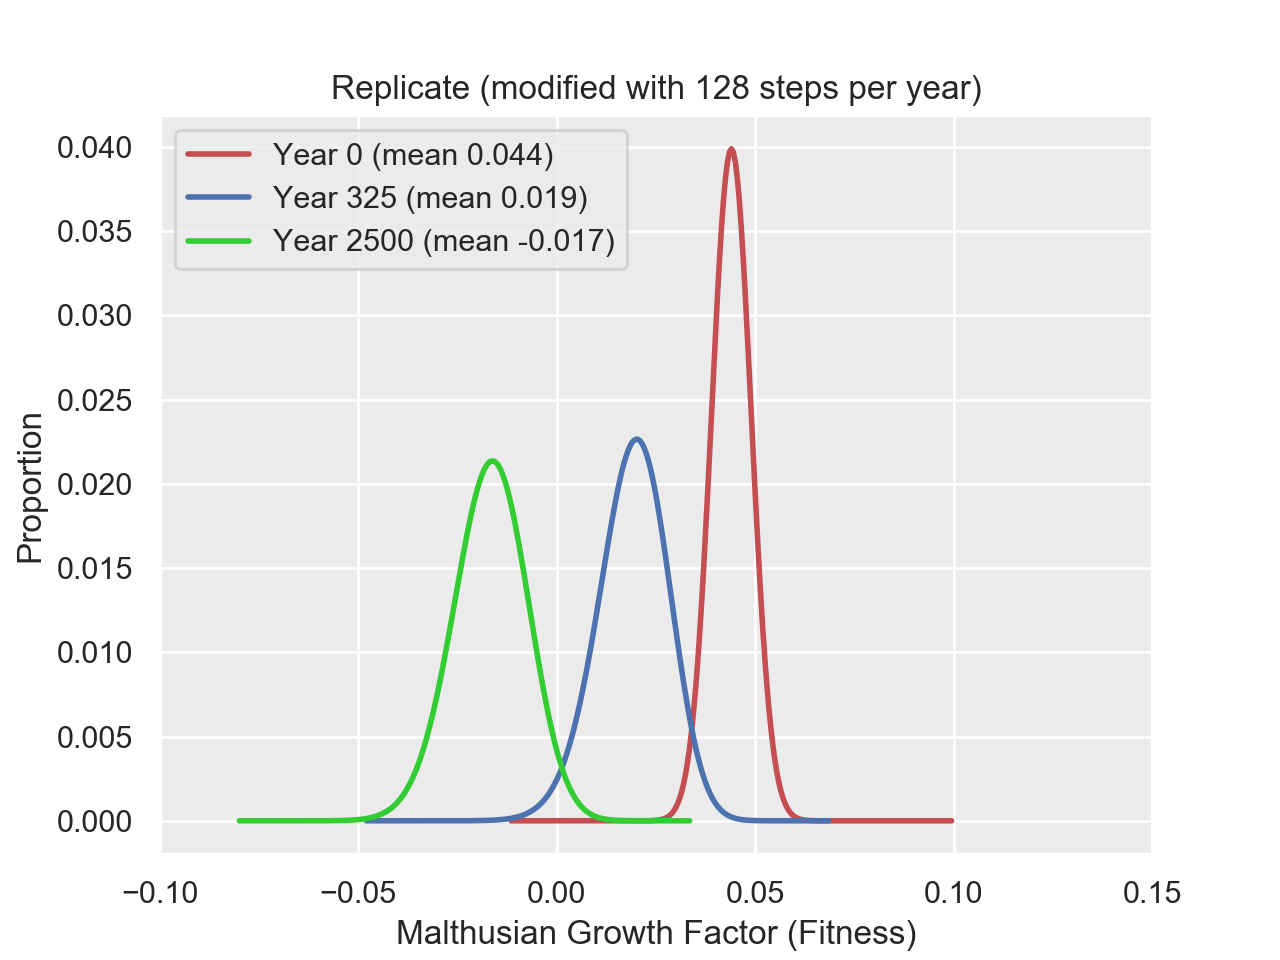

In [118]:
fig, ax = bs_plot(euler_solution, factors.growth, 325)
ax.set_title('Replicate (modified with 128 steps per year)')
ax.set_xlim(-0.10, 0.15);

<IPython.core.display.Javascript object>


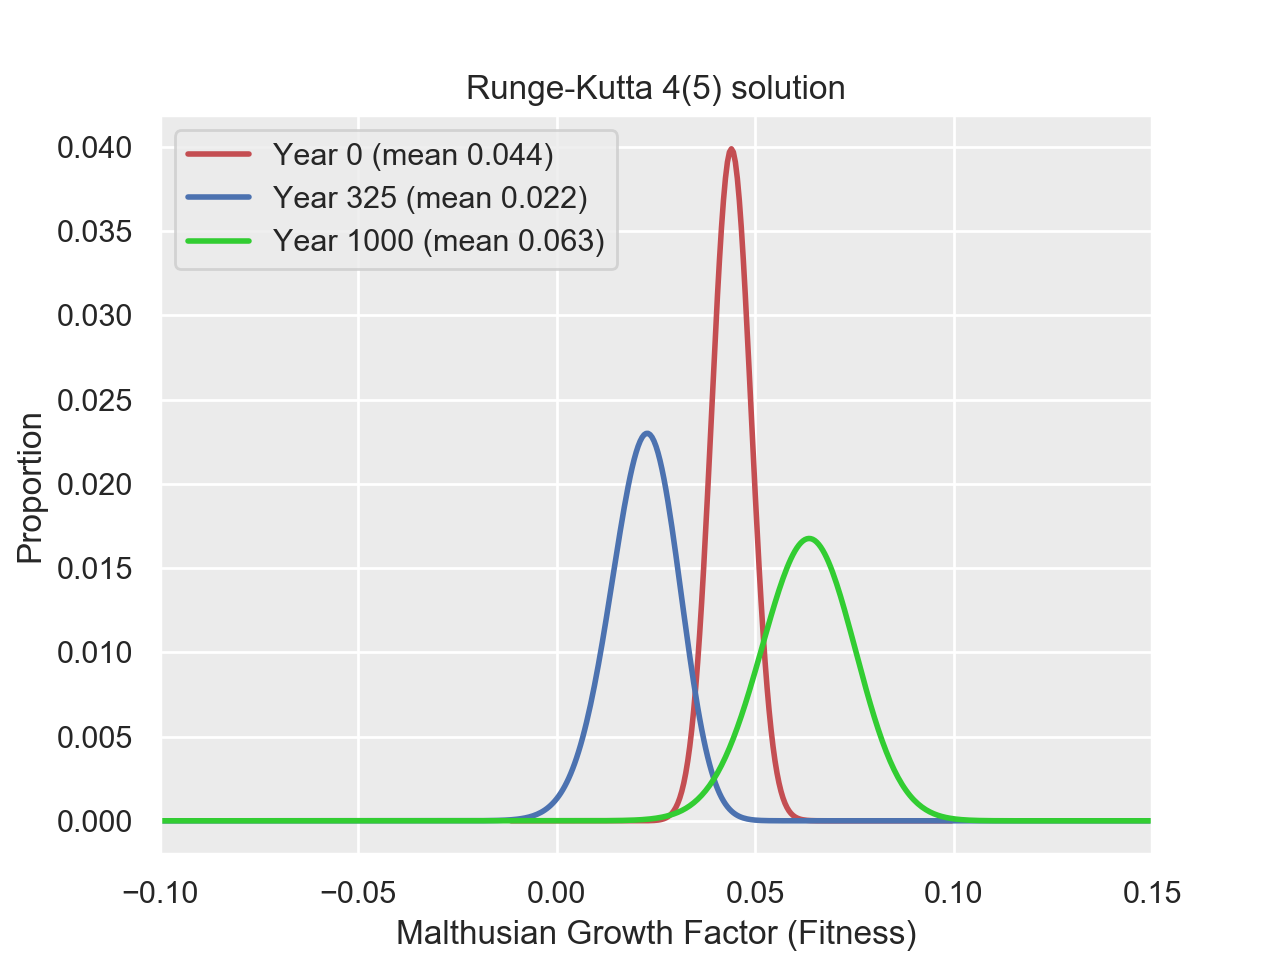

In [24]:
fig, ax = bs_plot(rk_solution, factors.growth, 325)
ax.set_title('Runge-Kutta 4(5) solution')
ax.set_xlim(-0.10, 0.15);

<IPython.core.display.Javascript object>


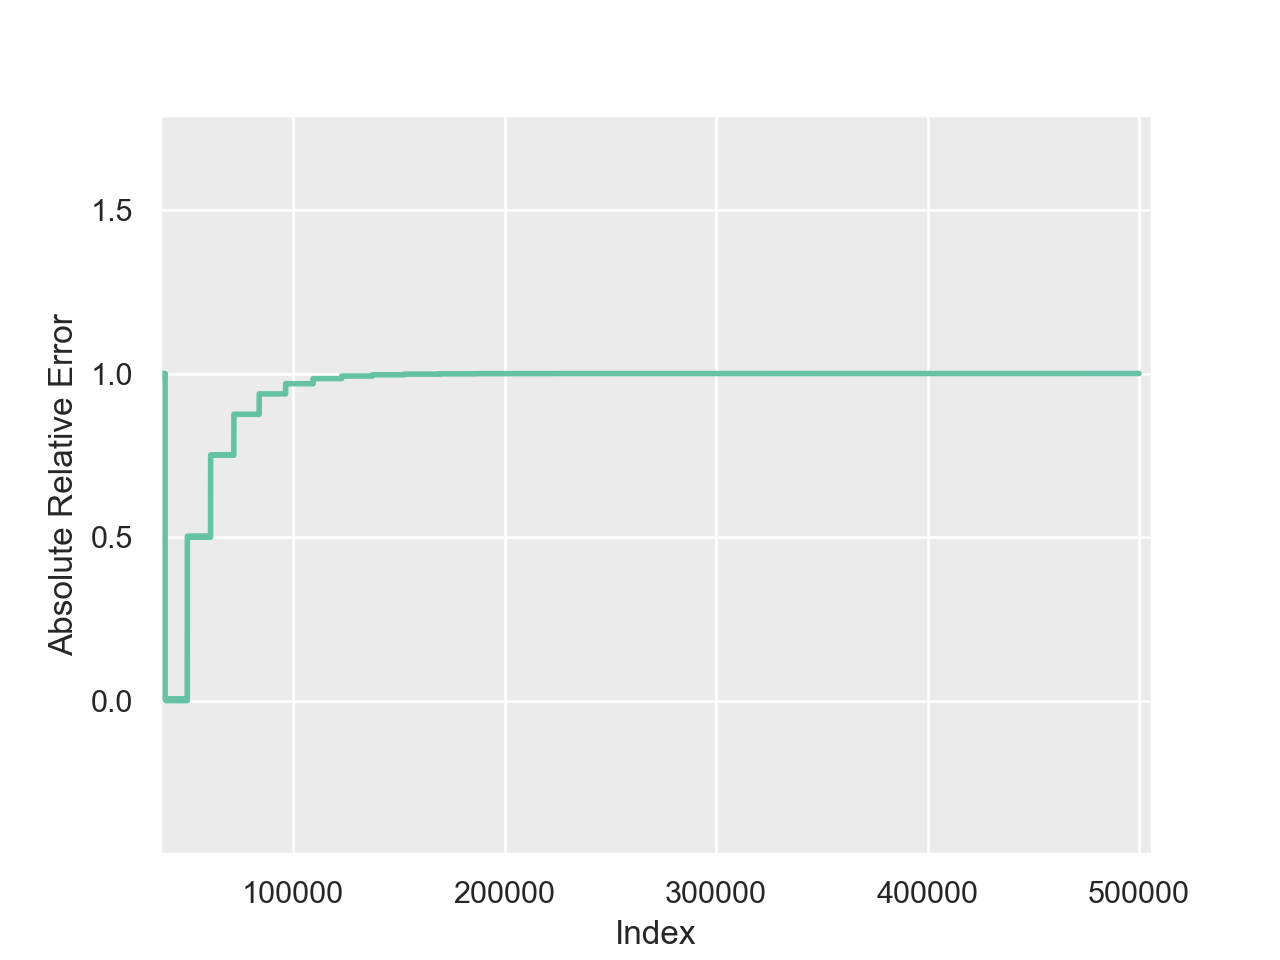

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x1a21890f28>)

In [37]:
flat_euler = euler_solution[1:].flatten()
flat_rk = rk_solution[1:].flatten()

def error_plot(errors):
    fig, ax = plt.subplots()
    ax.set_xlabel('Index')
    ax.set_ylabel('Absolute Relative Error')
    #colors = ['r', 'b', 'limegreen']
    ax.plot(range(len(errors)), errors)
    return fig, ax

error_plot(relative_error(flat_euler, flat_rk, absolute=True))

In [31]:
i = np.argmax(relative_error(flat_euler, flat_rk))
(flat_euler[i], flat_rk[i])

(0.0009399208836716681, 2.9372530394594723e-05)

## Substituting `BSless.js` for `BS.js`

Elsewhere in the binder, we will use `BSless.js` instead of `BS.js`. Unlike `BS.js`, `BSless.js`

1. normalizes the initial frequency distribution accurately,
2. calculates the numbers $\sum_j f_{ij} b_j P_j$ of type-$i$ births not-inaccurately, and
3. calculates the Gamma density function accurately.

Change 2 happens to make `BSless.js` run about 3 times as fast as `BS.js`. Changes 2 and 3 amount to calling functions in the `jStat` statistical package. They obviously are improvements to Basener's code (see "Implementation Details," below). In this section, we establish that change 1 is correct, and that the combined effects of the changes are in any case not large.

### No mutations (`None`)

In [21]:
%%time
case = 'None'
n = 625
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Infinite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSless.js',
               output_path='../Basener_Sanford_Data/bs5_2less.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_2less')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_2less.json
Done.
CPU times: user 3.96 s, sys: 297 ms, total: 4.25 s
Wall time: 20 s


In [22]:
with gzip.open('../Basener_Sanford_Data/bs5_2actual.pickled.gz') as f:
    data = pickle.load(f)
with gzip.open('../Basener_Sanford_Data/bs5_2less.pickled.gz') as f:
    less = pickle.load(f)

In [23]:
math.fsum(data['Psolution'][0]), math.fsum(less['Psolution'][0])

(0.9999999999999992, 1.0)

In [24]:
np.array_equal(less['P'] / math.fsum(less['P']), less['Psolution'][0])

True

In [25]:
# %load ../Code/plot_errors.py
def plot_errors(P, data, title):
    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Relative Error')
    e = [np.max(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data)]
    ax.plot(e, label='max absolute')
    e = [np.mean(relative_error(p[d>0], d[d>0], absolute=True)) for p, d in zip(P, data)]
    ax.plot(e, label='mean absolute')
    e = [np.mean(relative_error(p[d>0], d[d>0], absolute=False)) for p, d in zip(P, data)]
    ax.plot(e, label='mean signed')
    ax.legend(loc='upper left')
    return fig, ax

<IPython.core.display.Javascript object>


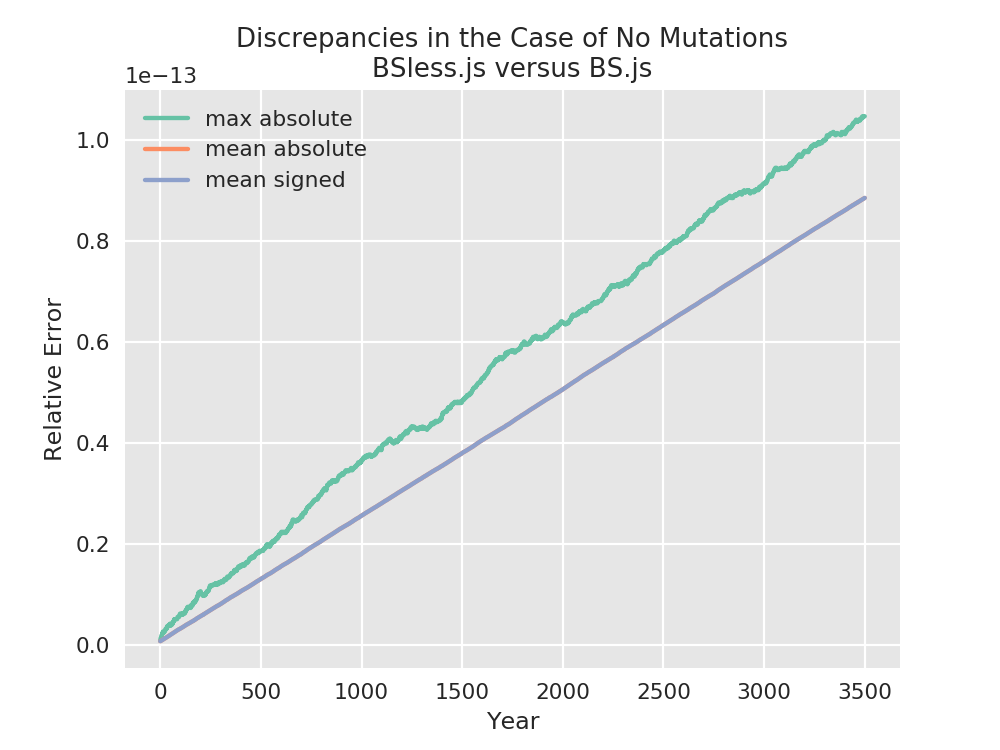

In [26]:
title = 'Discrepancies in the Case of No Mutations\nBSless.js versus BS.js'
fig, ax = plot_errors(less['Psolution'], data['Psolution'], title)

### Gaussian mutations

In [27]:
%%time
n = 250
case = 'Gaussian'
c = bs_command(percentage_of_mutations_that_are_beneficial=None,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSless.js',
               output_path='../Basener_Sanford_Data/bs5_3less.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_3less')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_3less.json
Done.
CPU times: user 310 ms, sys: 37 ms, total: 347 ms
Wall time: 2.04 s


In [28]:
with gzip.open('../Basener_Sanford_Data/bs5_3.pickled.gz') as f:
    data = pickle.load(f)
with gzip.open('../Basener_Sanford_Data/bs5_3less.pickled.gz') as f:
    less = pickle.load(f)

In [29]:
math.fsum(data['Psolution'][0]), math.fsum(less['Psolution'][0])

(1.0000000000000002, 1.0)

In [30]:
np.array_equal(less['P'] / math.fsum(less['P']), less['Psolution'][0])

True

<IPython.core.display.Javascript object>


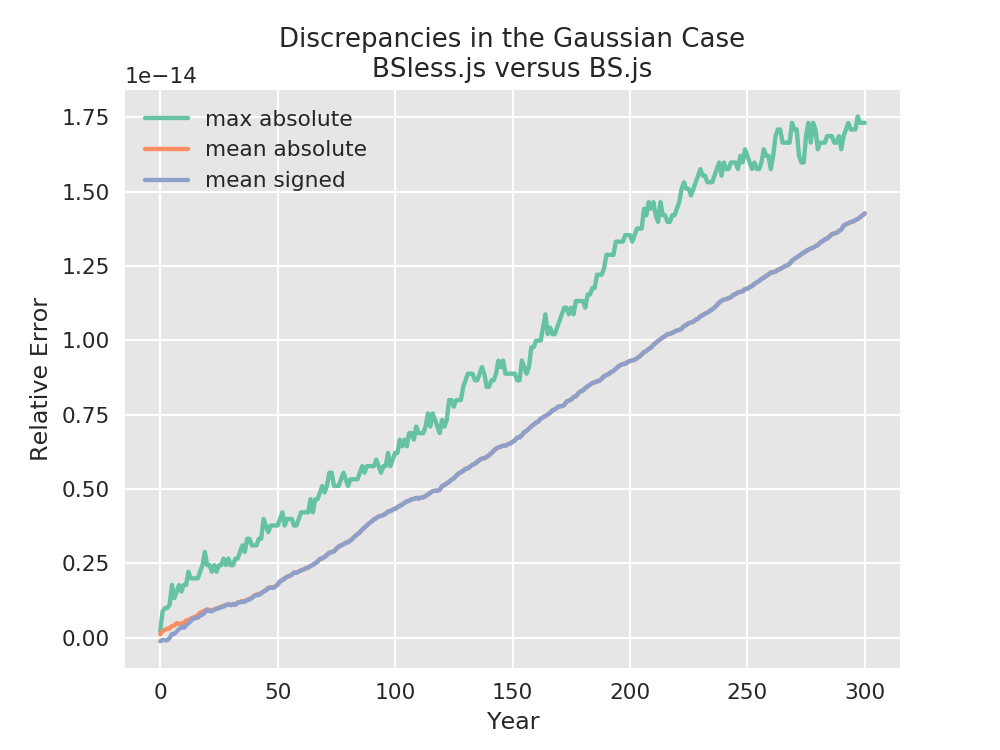

In [31]:
title = 'Discrepancies in the Gaussian Case\nBSless.js versus BS.js'
fig, ax = plot_errors(less['Psolution'], data['Psolution'], title)

### Gamma mutations

The differences in results for `BS.js` and `BSless.js` are very small in the `None` and `Gaussian` cases, and it perhaps seemed silly to bother with the changes. However, our primary concern in this binder is accounting for the results that Basener and Sanford report in Section 5.4 (`Gamma` case). As shown in the figure below, there is a substantial discrepancy in the outputs of the two versions of the code. Most of the discrepancy is due to my replacement of Basener's calculation of the Gamma density function with a call to a function in the `jStat` statistical package. The next section explains why Basener's calculation is inaccurate.

In [32]:
%%time
n = 500
case = 'Gamma'
c = bs_command(percentage_of_mutations_that_are_beneficial=0.001,
               mutation_distribution_type=case,
               population_size='Finite',
               number_of_years=N_YEARS[case],
               number_of_discrete_population_fitness_values=n,
               script_path='../Code/BSless.js',
               output_path='../Basener_Sanford_Data/bs5_4less.json')
!{c}
json_to_zipped_pickle('../Basener_Sanford_Data/bs5_4less')

Initializing.
Iterating.
Writing output to ../Basener_Sanford_Data/bs5_4less.json
Done.
CPU times: user 2.74 s, sys: 192 ms, total: 2.93 s
Wall time: 12.1 s


In [33]:
with gzip.open('../Basener_Sanford_Data/bs5_4.pickled.gz') as f:
    data = pickle.load(f)
with gzip.open('../Basener_Sanford_Data/bs5_4less.pickled.gz') as f:
    less = pickle.load(f)

In [34]:
math.fsum(data['Psolution'][0]), math.fsum(less['Psolution'][0])

(0.9999999999999999, 1.0)

In [35]:
np.array_equal(less['P'] / math.fsum(less['P']), less['Psolution'][0])

True

<IPython.core.display.Javascript object>


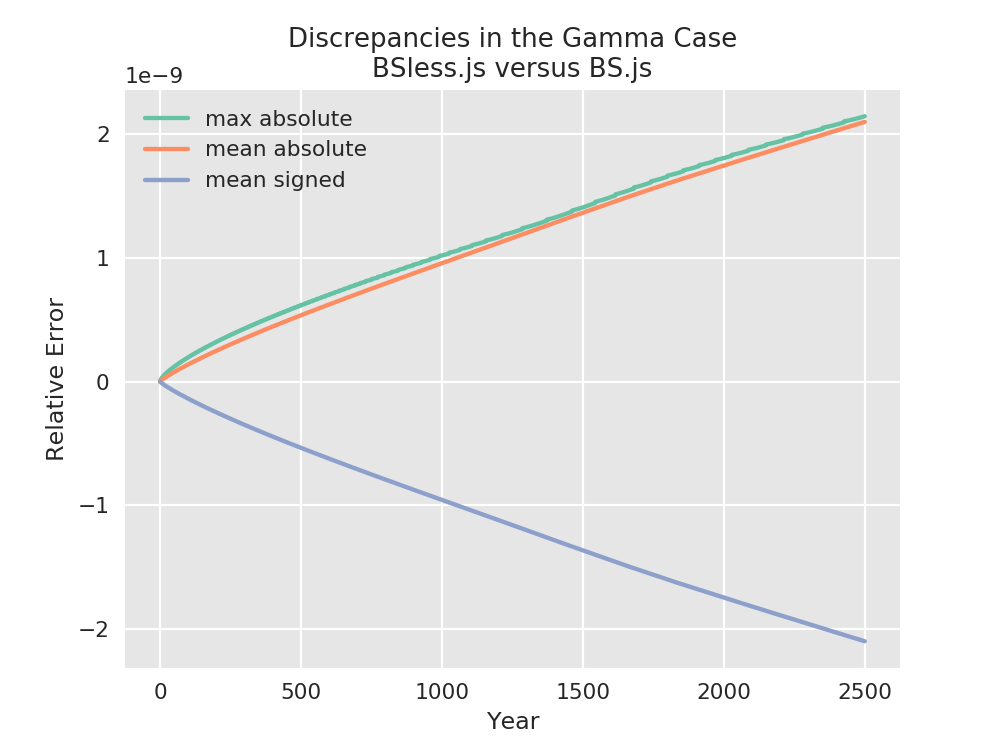

In [36]:
title = 'Discrepancies in the Gamma Case\nBSless.js versus BS.js'
fig, ax = plot_errors(less['Psolution'], data['Psolution'], title)

**Important: The population shrinks a bit more rapidly with the modified code than with the original.** 

Thus the substitution of `BSless.js` for `BS.js` works in favor of Basener and Sanford, not against against them.

## Clean up

I formerly included the compressed outputs of the programs in the binder. There's no longer much point in it, given the speed of `BSless.js`. We delete all of the data files generated by this notebook.

In [37]:
!rm ../Basener_Sanford_Data/bs5_*.json ../Basener_Sanford_Data/bs5_*.pickled.gz

## Implementation details

### `BS.js`

To make Basener's script usable from the command line, I have

1. deleted the part of Basener's script that generates graphics on the webpage,
2. replaced code that gets parameter settings from entries on the webpage with code that gets the settings from command-line arguments, and
3. added code to output the values of variables at the end of Basener's computation.

I have also defined, at the end of Basener's `runSimulation` function, an array `mutation_probs`, and have stored in it the values of Basener's `mutationProbs()` function for each of the possible changes in fitness due to mutation:

```javascript
var mutation_probs = new Array(2 * b.length - 1);
var zero_index = b.length - 1;

for (var i = 0; i < b.length; i++) {
    mutation_probs[zero_index - i] = mutationProb(-b[i], mDelta, mt);
    mutation_probs[zero_index + i] = mutationProb(b[i], mDelta, mt);
}
```

The array entry `b[i]` contains the Malthusian birth factor for the $i$-th type of organism. Basener does not pass elements of `b` to `mutationProb`, but instead differences `m[i] - m[j]` of Malthusian growth factors. The factors do not have exact binary representations, so `m[i] - m[j]` is generally not identical in magnitude to `b[abs(i - j)]` in practice as it is in theory.

### `BSless.js`



#### Summation of initial frequencies

Basener's code for calculating the initial frequency distribution was give above, in the section "Determining how B&S subdivided the fitness interval." I have replaced the loop doing simple summation of the probability densities in `P` with a call to a function implementing the [Kahan summation algorithm](https://en.wikipedia.org/wiki/Kahan_summation_algorithm).

```javascript
/*
s = 0;
for (i = 0; i < numIncrements; i++) {
    s = s + P[i]
}
*/
s = KahanSum(P);
```

I copied-and-pasted the code for `KahanSum` from the Wikipedia article on the algorithm, and made several minor changes to turn it into JavaScript. 

#### Summation of births

 Our detection of bias in the absence of mutation serves to underscore the atrociousness of his method for registering births. In the nested `for` loop of the following code segment, you will see that, rather than sum the numbers of births of type `i`, as indicated in Equation **???** of Basener and Sanford, Basener adds the numbers of births, one by one, to the current number of organisms of type `i`. Some of the numbers of births are very small in relation to the current number of organisms, and are consequently rounded to 0 in the summation. That is why Basener's updates of frequencies always produce frequencies that are smaller than our own.

```javascript
for (i = 0; i < numIncrements; i++) {

    // Never initialize an accumulator with a number much larger than
    // the remaining summands, as Basener does here:
    Psolution[t][i] = Psolution[t - 1][i];

    for (j = 0; j < numIncrements; j++) {
        // Relatively small addends (numbers of births) are rounded to 0.
        Psolution[t][i] = Psolution[t][i] + Psolution[t - 1][j] * MP[i][j];
    }

    Psolution[t][i] = Psolution[t][i] - deathRate * Psolution[t - 1][i];
    // snip
}
```

It is conceivable that Basener, a mathematician, is an incompetent programmer. However, we will see that he has elsewhere rigged his code brazenly. 

```javascript
for (i = 0; i < numIncrements; i++) {
    var births = jStat.dot(Psolution[t-1], MP[i]);
    Psolution[t][i] = births + (1 - deathRate) * Psolution[t - 1][i];
    // snip
}
```

The problem is needless imprecision in Basener's (oddly structured) calculation. I have copied [`BS.js`](../Code/BS.js) to [`BSalt.js`](../Code/BSalt.js), imported the `jStat` statistical package (which happens to provide a function to calculate the dot product of vectors), and introduced a bit of sanity:

If the error is honest, then Basener is incompetent to produce software for numerical studies. Note that we have eliminated, by way of simplification, a number of unnecessary indexing operations in the region of code that dominates execution time. Now we run `BSalt.js`, and again check the mean value of the absolute relative error.
```

#### Calculation of the Gamma density function```


In [42]:
np.isnan(np.nan)

True